In [71]:
import numpy as np
import time
from tqdm import tqdm
import matplotlib.pyplot as plt  # For visualizing input/reconstruction
import torch
import torch.nn as nn
import torch.nn.functional as F
from torch.utils.data import Dataset, DataLoader
import torchvision.transforms as transforms
import torch.optim as optim
#from pytorch_msssim import ms_ssim
from utils import ms_ssim
import seaborn as sns

# Data Loading

In [75]:
class CellDataset(Dataset):
    def __init__(self, img_path, label_path):
        self.images = np.load(img_path)[:, 0, :, :]  # Select only the first time point
        self.labels = np.load(label_path)
        
        # Normalize images to [0, 1] range
        self.images = self.images / 255.0

        self.transform = transforms.Compose([
            transforms.ToTensor(),
            transforms.Resize((20, 20)),  # Ensure images are correctly sized
            # transforms.Normalize(mean=[0.5], std=[0.5])  # One channel only
        ])

    def __len__(self):
        return len(self.images)

    def __getitem__(self, idx):
        img = self.images[idx]  # Shape: (H, W)
        label = self.labels[idx]

        img = torch.tensor(img, dtype=torch.float32).unsqueeze(0)  # Add channel dim (1, 20, 20)
        return img, label

# Load the data
dataset = CellDataset(
    img_path='lung_cancer_data/time_norm_train_images.npy',
    label_path='lung_cancer_data/train_labels_augmented4.npy'
)
data_loader = DataLoader(dataset, batch_size=32, shuffle=True)
print(f"Total batches: {len(data_loader)}")

Total batches: 69


In [76]:
print(f"Number of images in dataset: {len(dataset)}")
print(f"Number of batches in DataLoader: {len(data_loader)}")

Number of images in dataset: 2184
Number of batches in DataLoader: 69


In [77]:
img, label = dataset[0]  # Get the first image in the dataset
print(f"Image shape: {img.shape}")       # Print shape of the image
print(f"Image max value: {img.max()}")   # Print max value
print(f"Image min value: {img.min()}")   # Print min value

# Get the maximum value across the entire dataset
dataset_max = np.max(dataset.images)
print(f"Maximum value in the dataset: {dataset_max}")
print(f"Size of the dataset: {len(dataset)}")

Image shape: torch.Size([1, 20, 20])
Image max value: 0.0023016941267997026
Image min value: 0.0
Maximum value in the dataset: 0.00392156862745098
Size of the dataset: 2184


# Data Visualisation functions

In [5]:
def visualize_reconstructions(vae, dataloader, device):
    """
    Visualizes original and reconstructed images from the VAE.
    Adapted for 1-channel (grayscale) 20x20 images.
    Displays 5 examples in a 2-row grid:
      - Top row: original images.
      - Bottom row: corresponding reconstructions.
    """
    vae.eval()
    with torch.no_grad():
        for batch in dataloader:
            images = batch[0].to(device)
            recon_images, _, _ = vae(images)

            # Create a 2x5 grid: original on top, reconstruction below
            fig, axes = plt.subplots(2, 5, figsize=(15, 6))
            for i in range(5):  # Show 5 images
                # Original image (channel 0, since we have one channel)
                img_orig = images[i, 0].cpu().numpy()
                ax = axes[0, i]
                im = ax.imshow(img_orig, cmap="gray")
                ax.set_title("Original")
                ax.axis("off")
                fig.colorbar(im, ax=ax, fraction=0.046, pad=0.04)

                # Reconstructed image
                img_recon = recon_images[i, 0].cpu().numpy()
                ax = axes[1, i]
                im = ax.imshow(img_recon, cmap="gray")
                ax.set_title("Reconstructed")
                ax.axis("off")
                fig.colorbar(im, ax=ax, fraction=0.046, pad=0.04)

            plt.tight_layout()
            plt.show()
            break  # Only visualize the first batch

In [6]:
def plot_full_latent_space(vae, dataloader, device='cpu'):
    """
    Computes the latent vectors for all data points in the dataloader 
    and creates a scatter plot of the latent space colored by binary labels.
    Balances the classes by downsampling the majority class.
    """
    vae.eval()
    vae.to(device)

    all_zs = []
    all_labels = []

    with torch.no_grad():
        for batch_idx, (images, labels) in enumerate(dataloader):
            images = images.to(device)
            # Obtain latent variables via the encoder (using the reparameterization trick)
            mu, logvar = vae.encode(images)
            z = mu + torch.exp(0.5 * logvar) * torch.randn_like(mu)
            all_zs.append(z.cpu().numpy())
            # Convert labels to a NumPy array if needed
            all_labels.append(labels.numpy() if hasattr(labels, 'numpy') else np.array(labels))

    # Concatenate arrays from all batches
    all_zs = np.vstack(all_zs)
    all_labels = np.hstack(all_labels)

    # Balance classes: determine majority and minority classes
    unique_labels, label_counts = np.unique(all_labels, return_counts=True)
    label_minority = unique_labels[np.argmin(label_counts)]
    label_majority = unique_labels[np.argmax(label_counts)]
    minority_size = np.min(label_counts)

    print(f"Majority class ({label_majority}): {label_counts[np.argmax(label_counts)]}")
    print(f"Minority class ({label_minority}): {minority_size}")

    # Downsample the majority class to balance
    indices_majority = np.where(all_labels == label_majority)[0]
    indices_minority = np.where(all_labels == label_minority)[0]
    downsampled_majority_indices = np.random.choice(indices_majority, size=minority_size, replace=False)
    balanced_indices = np.concatenate((indices_minority, downsampled_majority_indices))

    all_zs = all_zs[balanced_indices]
    all_labels = all_labels[balanced_indices]

    print(f"After balancing: Total samples = {all_zs.shape[0]} (each class: {minority_size})")

    # Define fixed dark colors for each label (modify as desired)
    label_color_map = {
        unique_labels[0]: "#003366",  # Dark Navy Blue
        unique_labels[1]: "#FF4500"   # Dark Orange-Red
    }

    plt.figure(figsize=(8, 6))
    for label in unique_labels:
        mask = np.where(all_labels == label)[0]
        if len(mask) > 0:
            plt.scatter(all_zs[mask, 0], all_zs[mask, 1],
                        color=label_color_map[label], label=f"Label {label}",
                        alpha=0.7, s=10)
    plt.title('Latent Space (Balanced Labels)')
    plt.xlabel("z1")
    plt.ylabel("z2")
    plt.legend(title="Labels", loc="best")
    plt.tight_layout()
    plt.show()

In [60]:
class VAE_2Layer(nn.Module):
    def __init__(self, img_channels=1, latent_dim=2, img_size=20):
        super(VAE_2Layer, self).__init__()

        # ---------------------
        # Encoder (Less Aggressive)
        # ---------------------
        self.encoder = nn.Sequential(
            nn.Conv2d(img_channels, 32, kernel_size=3, padding=1),  # 20x20 → 20x20
            nn.ReLU(),
            nn.MaxPool2d(2),                                        # 20 → 10

            nn.Conv2d(32, 64, kernel_size=3, padding=1),            # 10x10 → 10x10
            nn.ReLU(),
            nn.MaxPool2d(2)                                         # 10 → 5
        )

        self.final_size = 5
        self.flat_dim = 64 * self.final_size * self.final_size  # 64 * 5 * 5 = 1600

        # ---------------------
        # Latent Space
        # ---------------------
        self.fc_mu = nn.Linear(self.flat_dim, latent_dim)
        self.fc_logvar = nn.Linear(self.flat_dim, latent_dim)
        self.fc_decode = nn.Linear(latent_dim, self.flat_dim)

        # ---------------------
        # Decoder
        # ---------------------
        self.decoder_blocks = nn.Sequential(
            nn.ConvTranspose2d(64, 32, kernel_size=4, stride=2, padding=1, output_padding=0),  # 5 → 10
            nn.ReLU(),

            nn.ConvTranspose2d(32, img_channels, kernel_size=4, stride=2, padding=1, output_padding=0),  # 10 → 20
            nn.Sigmoid()  # Ensure outputs are in [0, 1]
        )

    def encode(self, x):
        h = self.encoder(x)                       # (batch, 64, 5, 5)
        h_flat = h.view(x.size(0), -1)            # Flatten to (batch, 1600)
        mu = self.fc_mu(h_flat)                   # (batch, latent_dim)
        logvar = self.fc_logvar(h_flat)           # (batch, latent_dim)
        return mu, logvar

    def reparameterize(self, mu, logvar):
        std = torch.exp(0.5 * logvar)
        eps = torch.randn_like(std)
        return mu + eps * std

    def decode(self, z):
        h_flat = self.fc_decode(z)                # (batch, 1600)
        h = h_flat.view(-1, 64, self.final_size, self.final_size)  # (batch, 64, 5, 5)
        x_recon = self.decoder_blocks(h)          # (batch, 1, 20, 20)
        return x_recon

    def forward(self, x):
        mu, logvar = self.encode(x)
        z = self.reparameterize(mu, logvar)
        recon_x = self.decode(z)
        return recon_x, mu, logvar

In [61]:
# Instantiate the model for 20x20 images with 1 channel
device = torch.device('cuda' if torch.cuda.is_available() else 'cpu')
vae = VAE_2Layer(img_channels=1, latent_dim=2, img_size=20).to(device)
optimizer = optim.Adam(vae.parameters(), lr=1e-3)

#print(model)
#Additonal step:
scheduler = optim.lr_scheduler.StepLR(optimizer, step_size=10, gamma=0.5)

In [ ]:
def loss_function(recon_x, x, mu, logvar):
    # Reconstruction loss (MSE for pixel-level similarity)
    reconstruction_loss = F.mse_loss(recon_x, x, reduction='sum')
    #reconstruction_loss = F.mse_loss(recon_x, x, reduction='mean')
    #reconstruction_loss = ms_ssim(x, recon_x)
    
    kl_divergence = -0.5 * torch.sum(1 + logvar - mu.pow(2) - logvar.exp())
    kl_divergence = kl_divergence #/ x.size(0)

    return reconstruction_loss, kl_divergence

In [67]:
# Print number of trainable parameters
print(f"Number of trainable parameters: {sum(p.numel() for p in vae.parameters() if p.requires_grad)}")

Number of trainable parameters: 63333


In [ ]:
# Initialize lists to store losses for plotting
total_losses = []
reconstruction_losses = []
kl_losses = []

num_epochs = 50
kl_weight = 1e-5  # Start extremely small
vae.train()

# Variable to store reconstructed images for the last epoch
final_reconstructed_images = []

for epoch in range(num_epochs):
    kl_weight = min(1.0, kl_weight + 0.001)  # Gradually increase KL weight

    epoch_total_loss = 0
    epoch_recon_loss = 0
    epoch_kl_loss = 0
    
    with tqdm(data_loader, unit="batch") as tepoch:
        for batch_idx, (images, _) in enumerate(tepoch):  # Updated unpacking to match CellDataset
            tepoch.set_description(f"Epoch {epoch+1}")

            images = images.to(device)
            
            # Print shape of images before input to the VAE
            print(f"Batch {batch_idx}: Training Data Shape: {images.shape}")  # Expect (batch_size, 1, 20, 20)

            optimizer.zero_grad()  # Zero gradients
            
            recon_images, mu, logvar = vae(images)  # Forward pass
            
            # Print shape of latent space
            print(f"Batch {batch_idx}: Latent Space Shape (mu): {mu.shape}")    # Expect (batch_size, latent_dim)
            print(f"Batch {batch_idx}: Latent Space Shape (logvar): {logvar.shape}")  # Expect (batch_size, latent_dim)
            
            # Compute losses
            recon_loss, kl_loss = loss_function(recon_images, images, mu, logvar)
            scaled_loss = recon_loss + kl_weight * kl_loss
            
            scaled_loss.backward()  # Backward pass
            
            torch.nn.utils.clip_grad_norm_(vae.parameters(), max_norm=1)  # Gradient clipping
            
            optimizer.step()  # Optimizer step
            
            # Accumulate losses for the epoch
            epoch_total_loss += scaled_loss.item()
            epoch_recon_loss += recon_loss.item()
            epoch_kl_loss += kl_loss.item()
            
            # If it's the final epoch, collect reconstructed images
            if epoch == num_epochs - 1:
                final_reconstructed_images.append(recon_images.cpu())
            
            tepoch.set_postfix(
                recon_loss=recon_loss.item(),
                kl_loss=kl_loss.item(),
                total_loss=scaled_loss.item()
            )

    # Calculate average losses for the epoch
    avg_total_loss = epoch_total_loss / len(data_loader)
    avg_recon_loss = epoch_recon_loss / len(data_loader)
    avg_kl_loss = epoch_kl_loss / len(data_loader)

    # Store the average losses
    total_losses.append(avg_total_loss)
    reconstruction_losses.append(avg_recon_loss)
    kl_losses.append(avg_kl_loss)
    
    scheduler.step()
    print(f"Epoch {epoch+1}: Loss = {avg_total_loss / len(data_loader.dataset):.4f}")

# After training, concatenate all reconstructed images across epochs
final_reconstructed_images = torch.cat(final_reconstructed_images, dim=0)


  0%|          | 0/9 [00:00<?, ?batch/s]

Epoch 1:  11%|█         | 1/9 [00:00<00:01,  6.16batch/s, kl_loss=-0, recon_loss=0.000328, total_loss=0.000328]

Batch 0: Training Data Shape: torch.Size([32, 1, 20, 20])
Batch 0: Latent Space Shape (mu): torch.Size([32, 2])
Batch 0: Latent Space Shape (logvar): torch.Size([32, 2])
Batch 1: Training Data Shape: torch.Size([32, 1, 20, 20])
Batch 1: Latent Space Shape (mu): torch.Size([32, 2])
Batch 1: Latent Space Shape (logvar): torch.Size([32, 2])
Batch 2: Training Data Shape: torch.Size([32, 1, 20, 20])


Epoch 1:  44%|████▍     | 4/9 [00:00<00:00, 13.73batch/s, kl_loss=-0, recon_loss=0.000316, total_loss=0.000316]

Batch 2: Latent Space Shape (mu): torch.Size([32, 2])
Batch 2: Latent Space Shape (logvar): torch.Size([32, 2])
Batch 3: Training Data Shape: torch.Size([32, 1, 20, 20])
Batch 3: Latent Space Shape (mu): torch.Size([32, 2])
Batch 3: Latent Space Shape (logvar): torch.Size([32, 2])
Batch 4: Training Data Shape: torch.Size([32, 1, 20, 20])
Batch 4: Latent Space Shape (mu): torch.Size([32, 2])
Batch 4: Latent Space Shape (logvar): torch.Size([32, 2])
Batch 5: Training Data Shape: torch.Size([32, 1, 20, 20])


...

Batch 4: Training Data Shape: torch.Size([32, 1, 20, 20])


Epoch 500:  67%|██████▋   | 6/9 [00:00<00:00,  8.68batch/s, kl_loss=1.86e-9, recon_loss=0.000323, total_loss=0.000323]

Batch 4: Latent Space Shape (mu): torch.Size([32, 2])
Batch 4: Latent Space Shape (logvar): torch.Size([32, 2])
Batch 5: Training Data Shape: torch.Size([32, 1, 20, 20])
Batch 5: Latent Space Shape (mu): torch.Size([32, 2])
Batch 5: Latent Space Shape (logvar): torch.Size([32, 2])
Batch 6: Training Data Shape: torch.Size([32, 1, 20, 20])
Batch 6: Latent Space Shape (mu): torch.Size([32, 2])
Batch 6: Latent Space Shape (logvar): torch.Size([32, 2])
Batch 7: Training Data Shape: torch.Size([32, 1, 20, 20])


Epoch 500: 100%|██████████| 9/9 [00:00<00:00,  9.84batch/s, kl_loss=-0, recon_loss=0.000317, total_loss=0.000317]     

Batch 7: Latent Space Shape (mu): torch.Size([32, 2])
Batch 7: Latent Space Shape (logvar): torch.Size([32, 2])
Batch 8: Training Data Shape: torch.Size([21, 1, 20, 20])
Batch 8: Latent Space Shape (mu): torch.Size([21, 2])
Batch 8: Latent Space Shape (logvar): torch.Size([21, 2])
Epoch 500: Loss = 0.0000


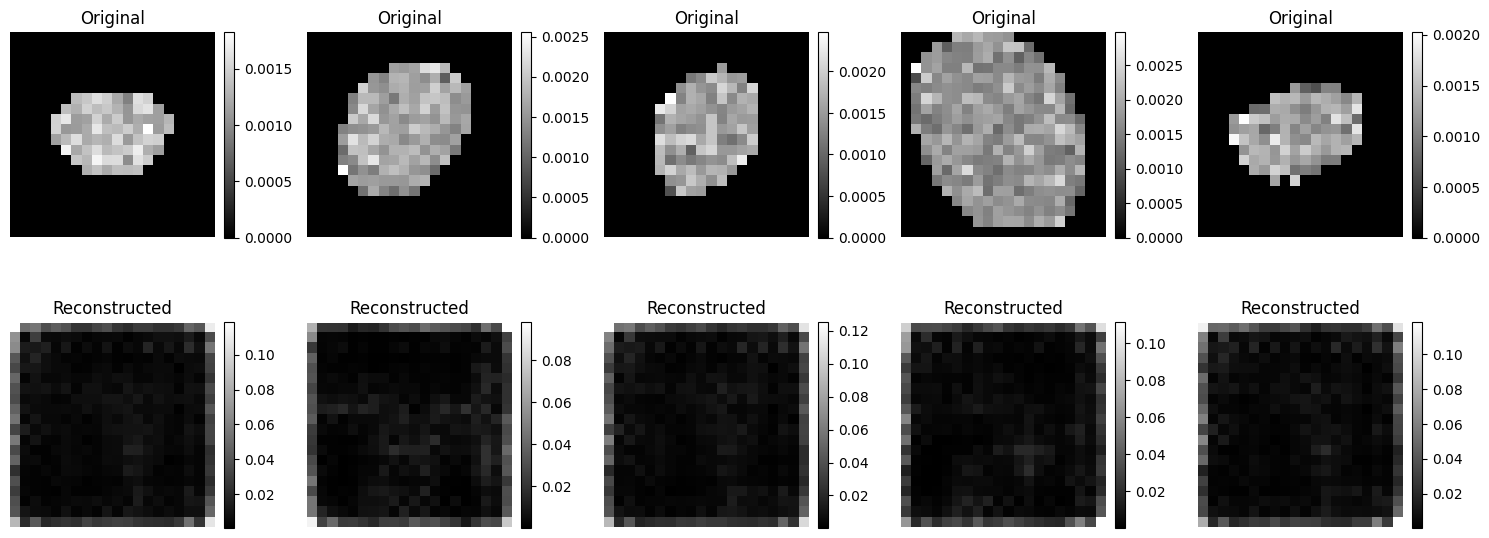

In [69]:
visualize_reconstructions(vae, data_loader, device)

Majority class (0): 140
Minority class (1): 137
After balancing: Total samples = 274 (each class: 137)


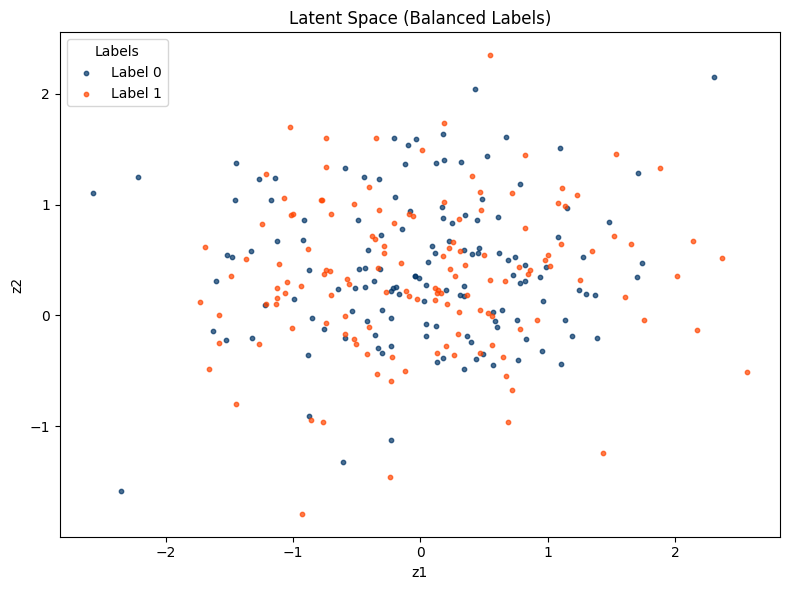

In [29]:
plot_full_latent_space(vae, data_loader, device=device)